<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/dust_extinction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autor:** Diego Gutierrez

**Objetivo:** Develop a computational model of galactic radiation fields by simulating stellar distributions, interstellar extinction, dust heating, and radiative transfer to reproduce observable infrared emission properties.

##a) *Simulando la distribución uniforme de las estrellas en una galaxia*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.integrate import quad

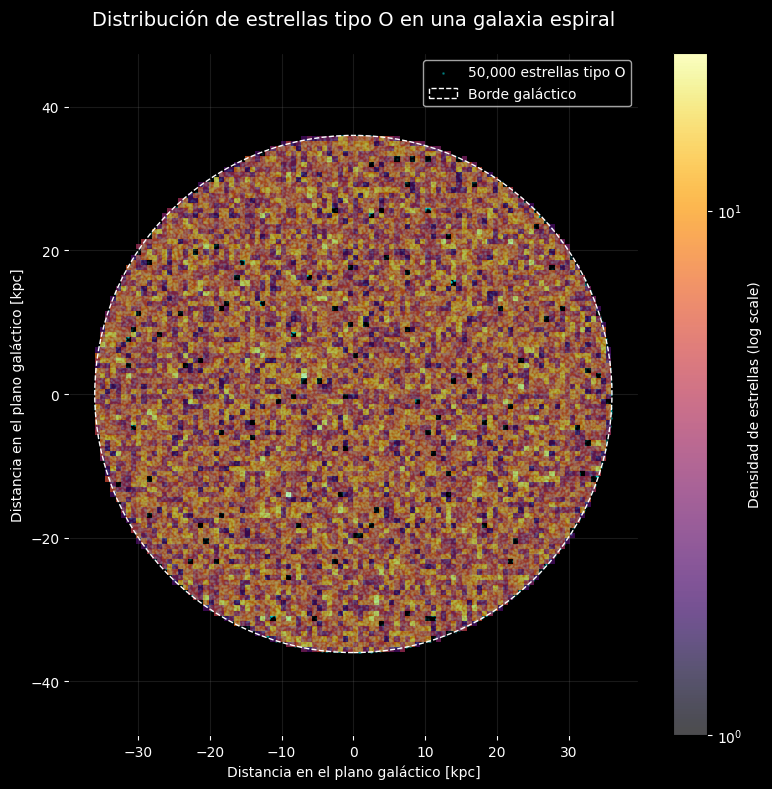

In [2]:
# Configuración de parámetros
N_o = int(5e4)          # Número de estrellas tipo O
r_gal = 36              # Radio de la galaxia en kpc
np.random.seed(50)      # Semilla para reproducibilidad

# Generar coordenadas polares con distribución uniforme en el área
r = r_gal * np.sqrt(np.random.rand(N_o))
theta = 2 * np.pi * np.random.rand(N_o)

# Convertir a coordenadas cartesianas
x = r * np.cos(theta)
y = r * np.sin(theta)

# Visualización mejorada
plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Dos representaciones: scatter plot e histograma 2D (densidad)
plt.scatter(x, y, s=1, color='cyan',
            alpha=0.3, label=f'{N_o:,} estrellas tipo O')
plt.hist2d(x, y, bins=100, norm=LogNorm(), cmap='inferno', alpha=0.7)

# Añadir círculo para mostrar el borde de la galaxia
borde_gal = plt.Circle((0, 0), r_gal, color='white', fill=False,
                         linestyle='--', linewidth=1, label='Borde galáctico')
ax.add_patch(borde_gal)

# Configuración del gráfico
plt.title('Distribución de estrellas tipo O en una galaxia espiral',
          color='white', pad=20, fontsize=14)
plt.xlabel('Distancia en el plano galáctico [kpc]', color='white')
plt.ylabel('Distancia en el plano galáctico [kpc]', color='white')
plt.axis('equal')
plt.grid(True, color='gray', alpha=0.2)
plt.legend(loc='upper right', facecolor='black', labelcolor='white')

# Colorbar para el histograma de densidad
cbar = plt.colorbar()
cbar.set_label('Densidad de estrellas (log scale)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Ajustar los colores de los ejes
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()

## b) *Flujo de todas las estrellas tipo O*

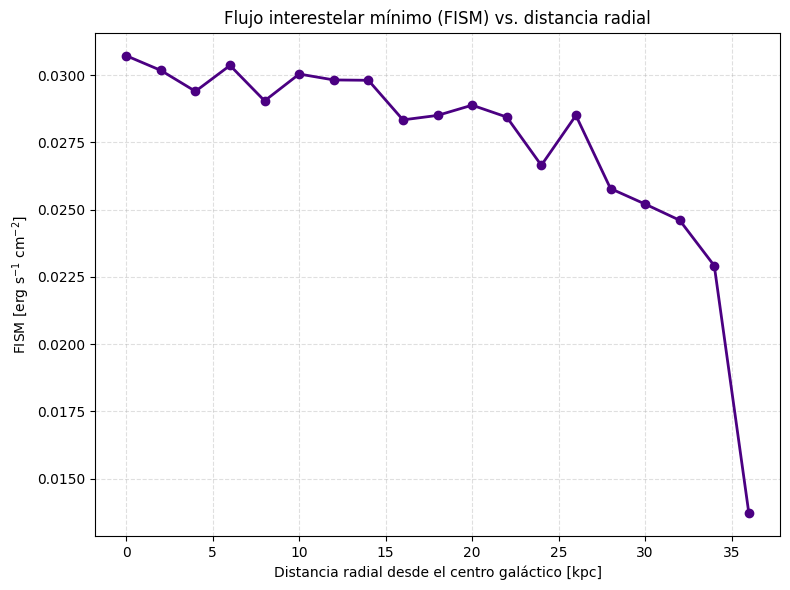

In [3]:
# Parámetros adicionales
L_o = 1e40                         # Luminosidad de una estrella tipo O [erg/s]
kpc_to_cm = 3.086e21               # Conversión de kpc a cm
n_sim = 50                         # Número de simulaciones para estimar FISM
r_eval = np.arange(0, r_gal + 2, 2)  # Radios donde se evalúa el flujo en kpc
r_eval_cm = r_eval * kpc_to_cm     # Conversión a cm

# Inicializar matriz para almacenar flujos simulados
matriz_F = np.zeros((n_sim, len(r_eval)))

for sim in range(n_sim):
    # Re-generar una distribución aleatoria de estrellas tipo O
    r_sim = r_gal * np.sqrt(np.random.rand(N_o))
    theta_sim = 2 * np.pi * np.random.rand(N_o)
    x_sim = r_sim * np.cos(theta_sim) * kpc_to_cm
    y_sim = r_sim * np.sin(theta_sim) * kpc_to_cm

    for i, rs in enumerate(r_eval_cm):
        # Punto de evaluación (en eje x)
        xs, ys = rs, 0.0

        # Calcular distancia a todas las estrellas
        d = np.sqrt((x_sim - xs)**2 + (y_sim - ys)**2)

        # Evitar distancias absurdamente pequeñas (< 0.03 kpc ~ 1e19 cm)
        d[d < 1e19] = 1e19

        # Calcular el flujo total
        flujo_total = np.sum(L_o / (4 * np.pi * d**2))  # [erg/s/cm^2]
        matriz_F[sim, i] = flujo_total

# Tomar el mínimo flujo entre simulaciones para cada r
FISM = np.min(matriz_F, axis=0)

# Gráfico del flujo FISM vs. distancia radial
plt.figure(figsize=(8, 6))
plt.plot(r_eval, FISM, marker='o', color='indigo', linewidth=2)
plt.xlabel('Distancia radial desde el centro galáctico [kpc]')
plt.ylabel('FISM [erg s$^{-1}$ cm$^{-2}$]')
plt.title('Flujo interestelar mínimo (FISM) vs. distancia radial')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

##c) Agregando extinción al flujo hallado con coeficiente $a_λ = 1.5 \space mag \space
Kpc^{-1}$

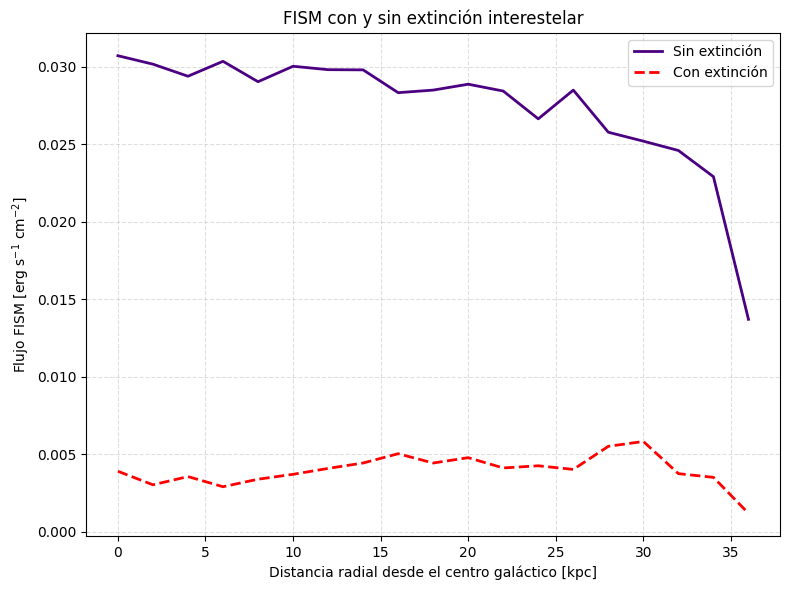

In [4]:
# Parámetros de extinción
a_lambda = 1.5  # magnitudes por kpc

# Nueva matriz para almacenar flujos atenuados
matriz_f_ext = np.zeros((n_sim, len(r_eval)))

for sim in range(n_sim):
    # Re-generar distribución estelar como antes
    r_sim = r_gal * np.sqrt(np.random.rand(N_o))
    theta_sim = 2 * np.pi * np.random.rand(N_o)
    x_sim = r_sim * np.cos(theta_sim)
    y_sim = r_sim * np.sin(theta_sim)

    # Convertir también a cm para flujo
    x_sim_cm = x_sim * kpc_to_cm
    y_sim_cm = y_sim * kpc_to_cm

    for i, r_eval_k in enumerate(r_eval):
        # Punto de evaluación
        px_kpc = r_eval_k
        py_kpc = 0.0

        # Distancias en kpc (para extinción)
        d_kpc = np.sqrt((x_sim - px_kpc)**2 + (y_sim - py_kpc)**2)

        # Distancias en cm (para flujo)
        d_cm = d_kpc * kpc_to_cm
        d_cm[d_cm < 1e19] = 1e19

        # Extinción en magnitudes
        A_lambda = a_lambda * d_kpc

        # Atenuación del flujo
        atenuacion = 10**(-0.4 * A_lambda)

        # Flujo total con extinción
        F_ext = np.sum((L_o / (4 * np.pi * d_cm**2)) * atenuacion)
        matriz_f_ext[sim, i] = F_ext

# Tomar el mínimo entre simulaciones para cada radio
FISM_ext = np.min(matriz_f_ext, axis=0)

# Gráfico comparativo
plt.figure(figsize=(8, 6))
plt.plot(r_eval, FISM, label='Sin extinción', color='indigo', linewidth=2)
plt.plot(r_eval, FISM_ext, label='Con extinción', color='red',
         linestyle='--', linewidth=2)
plt.xlabel('Distancia radial desde el centro galáctico [kpc]')
plt.ylabel('Flujo FISM [erg s$^{-1}$ cm$^{-2}$]')
plt.title('FISM con y sin extinción interestelar')
#plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

##d) *Energía y flujo de fotones*


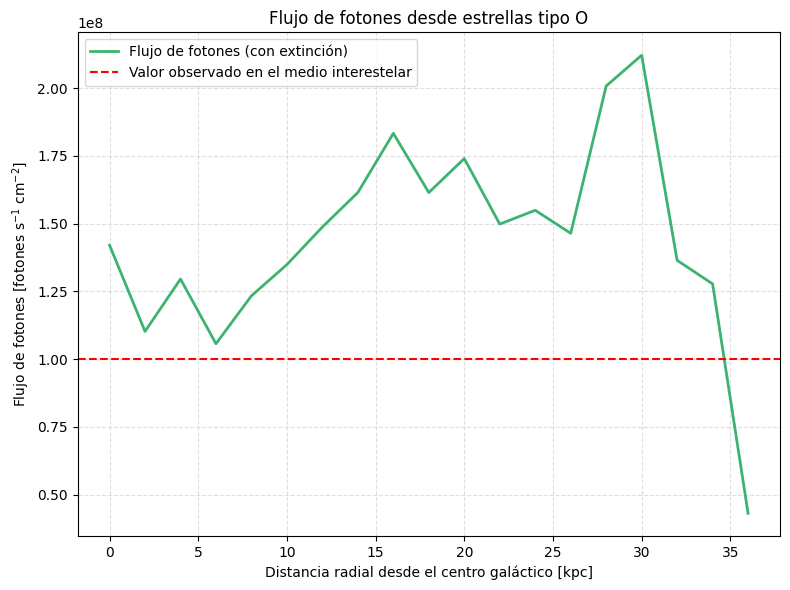

In [5]:
# Constantes
h = 6.626e-27         # erg·s
c = 3e10              # cm/s
b_wien = 2.897e-3     # m·K
T_o = 4e4             # K

# Longitud de onda pico (Ley de Wien)
lambda_peak_cm = (b_wien / T_o) * 100 #en cm

# Energía de un fotón en el pico
E_photon = h * c / lambda_peak_cm      # en erg

# Flujo de fotones = flujo energético / energía por fotón
phi_photon = FISM_ext / E_photon       # en fotones/s/cm^2

# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(r_eval, phi_photon, color='mediumseagreen',
         linewidth=2, label='Flujo de fotones (con extinción)')
plt.axhline(1e8, color='red', linestyle='--',
            label='Valor observado en el medio interestelar')
plt.xlabel('Distancia radial desde el centro galáctico [kpc]')
plt.ylabel('Flujo de fotones [fotones s$^{-1}$ cm$^{-2}$]')
plt.title('Flujo de fotones desde estrellas tipo O')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

##e) *Temperatura de equilibrio de los granos de polvo interestelar*


La radiación interestelar $ F_{\text{ISM}} $ calienta los granos de polvo en el medio interestelar. En equilibrio térmico, los granos reemiten toda la energía absorbida, de modo que:

$$
F_{\text{abs}} = F_{\text{em}}
$$

La emisión del grano de polvo no sigue exactamente la ley de un cuerpo negro, debido a su eficiencia de emisión $ Q_\lambda $, por lo tanto:

$$
F_{\text{em}} = \sigma T_g^4 \cdot Q_\lambda
$$

Donde $ \sigma $ es la constante de Stefan-Boltzmann, y $ T_g $ es la temperatura de equilibrio del grano.

Según la teoría de Mie, para granos pequeños que emiten en el infrarrojo ($ \lambda_g > 2\pi a $), la eficiencia puede aproximarse por:

$$
Q_\lambda \approx \left( \frac{2\pi a}{\lambda_g} \right)^\beta
$$

Y usando la ley de Wien:

$$
\lambda_g = \frac{b}{T_g}
$$

Donde $ b $ es la constante de desplazamiento de Wien. Sustituyendo, obtenemos:

$$
Q_\lambda \approx \left( \frac{2\pi a T_g}{b} \right)^\beta
$$

Reemplazando en la ecuación de emisión:

$$
F_{\text{ISM}} = \sigma T_g^4 \cdot \left( \frac{2\pi a T_g}{b} \right)^\beta
= \sigma \left( \frac{2\pi a}{b} \right)^\beta \cdot T_g^{4 + \beta}
$$

Despejando $ T_g $:

$$
T_g = \left( \frac{F_{\text{ISM}}}{\sigma \left( \frac{2\pi a}{b} \right)^\beta} \right)^{\frac{1}{4 + \beta}}
$$

Esta expresión permite calcular la temperatura de equilibrio del polvo interestelar en función del flujo de radiación recibido.


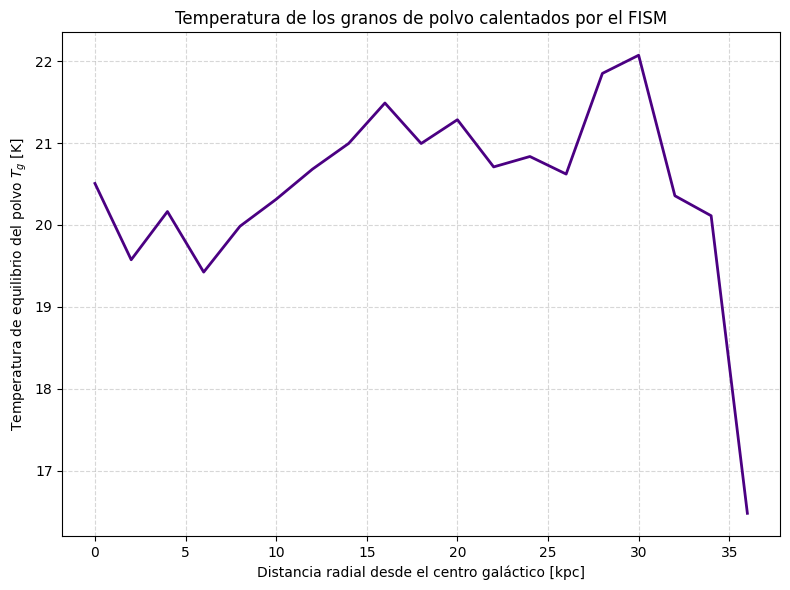

In [6]:
# Constantes
sigma = 5.67e-5             # Stefan-Boltzmann [erg / s / cm^2 / K^4]
b_wien_cmK = b_wien *  100  # cm·K (convertido de m·K)
a_size = 1e-5               # cm (0.1 micrometros)
beta = 1.45

# Prefactor constante
prefactor = sigma * (2 * np.pi * a_size / b_wien_cmK)**beta

# Temperatura de equilibrio (para cada FISM_ext)
Tg = (FISM_ext / prefactor)**(1 / (4 + beta))  # en K

# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(r_eval, Tg, color='indigo', linewidth=2)
plt.xlabel('Distancia radial desde el centro galáctico [kpc]')
plt.ylabel('Temperatura de equilibrio del polvo $T_g$ [K]')
plt.title('Temperatura de los granos de polvo calentados por el FISM')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##f) *Calculando el valor de $a_λ$ con la temperatura promedio*

In [7]:
# Densidad de número de polvo
n_d = 2e-13                     # cm^-3

# Temperatura promedio de los granos
Tg_avg = np.mean(Tg)
lambda_g = b_wien_cmK / Tg_avg  # cm

# Eficiencia Q_lambda
Q_lambda = (2 * np.pi * a_size / lambda_g)**beta

# Cálculo de a_lambda en mag/kpc
a_lambda_Exp = 1.086 * n_d * np.pi * a_size**2 * Q_lambda* kpc_to_cm


print(f"Longitud de onda  ≈ {lambda_g:.5f} cm")
print(f"Coeficiente de extinción a_lambda_Exp ≈ {a_lambda_Exp:.5f} mag/kpc")

Longitud de onda  ≈ 0.01417 cm
Coeficiente de extinción a_lambda_Exp ≈ 0.00008 mag/kpc


La gran diferencia entre los coeficientes de extinción obtenidos en los incisos (c) y (f) se debe principalmente a la fuerte dependencia de la eficiencia de absorción del polvo interestelar, $Q_\lambda$, con la longitud de onda $\lambda$.

En el inciso (c), se considera radiación estelar en el ultravioleta u óptico, con $\lambda \sim 0.1\,\mu\text{m}$, donde los granos de polvo, cuyo tamaño típico es $a \sim 0.1\,\mu\text{m}$, presentan una eficiencia de absorción alta, es decir, $Q_\lambda \sim 1$. En contraste, en el inciso (f), la radiación considerada es la emitida térmicamente por los granos de polvo, con una longitud de onda característica en el infrarrojo lejano, $\lambda_g \sim 140\,\mu\text{m}$. En este régimen, donde $\lambda \gg a$, la eficiencia de absorción disminuye drásticamente según la teoría de Mie, siguiendo la relación:

$$
Q_\lambda \propto \left( \frac{2\pi a}{\lambda} \right)^\beta,
$$

con $\beta \approx 1.45$. Esto hace que $Q_\lambda$ y, por ende, el coeficiente de extinción $a_\lambda$ sean mucho menores en el infrarrojo que en el ultravioleta.

En resumen, el polvo interestelar es muy eficiente absorbiendo la luz estelar, pero casi transparente a su propia emisión térmica en el infrarrojo lejano. Por esta razón, se obtiene que $a_\lambda^{(\text{f})} \ll a_\lambda^{(\text{c})}$.


##g) *Calculando la intensidad $Iν$ en el centro de la galaxia y emitida por el polvo galáctico.*

In [8]:
# Constantes físicas
k = 1.381e-16                # erg/K (constante de Boltzmann)
L = r_gal * kpc_to_cm        # Longitud del disco galáctico en cm (36 kpc)

# frecuencia del pico de emisión del polvo
nu_g = c / lambda_g

# Profundidad óptica τ_ν = n_d * σ * L con σ = πa² * Q_lambda
tao = n_d * Q_lambda * np.pi * a_size**2 * L

# Función fuente B_ν usando la ley de Planck
expo = h * nu_g / (k * Tg_avg)
B_nu = (2 * h * nu_g**3 / c**2) / (np.exp(expo) - 1)

# Solución de la ecuación de transferencia radiativa: I_ν = B_ν (1 - e^{-τ})
I_nu = B_nu * (1 - np.exp(-tao))

# Mostrar resultados
print(f"La intensidad I_ν ≈ {I_nu:.5e} erg s⁻¹ cm⁻² Hz⁻¹ sr⁻¹")

La intensidad I_ν ≈ 2.64053e-15 erg s⁻¹ cm⁻² Hz⁻¹ sr⁻¹


A partir de la solución de la ecuación de transferencia radiativa para el polvo interestelar, se obtuvo una intensidad espectral en el centro de la galaxia de:

$$
I_\nu \approx 2.64 \times 10^{-15} \; \text{erg} \; \text{s}^{-1} \, \text{cm}^{-2} \, \text{Hz}^{-1} \, \text{sr}^{-1}
$$

Este resultado se encuentra aproximadamente un orden de magnitud por debajo del valor promedio observado en el medio interestelar, que es:

$$
I_{\nu, \, \text{obs}} \sim 1 \times 10^{-14} \; \text{erg} \; \text{s}^{-1} \, \text{cm}^{-2} \, \text{Hz}^{-1} \, \text{sr}^{-1}
$$

La diferencia es esperada considerando que el modelo utilizado es simplificado: se asumió una temperatura uniforme del polvo ($T_g \sim 20.44 \, \text{K}$), emisión en equilibrio térmico con eficiencia de Mie ($Q_\lambda < 1$), y profundidad óptica baja ($\tau_\nu \ll 1$). En este régimen, la intensidad resultante se aproxima por:

$$
I_\nu \approx B_\nu(T_g) \cdot \tau_\nu
$$

lo cual reduce el valor de $I_\nu$ respecto al máximo posible para una fuente completamente opaca. A pesar de estas simplificaciones, el orden de magnitud es consistente con las observaciones, lo que indica que la emisión térmica del polvo puede explicar una fracción significativa del fondo infrarrojo galáctico.

##h) *Cálculo del coeficiente de extinción $a_λ$* y del radio fiducial $R_V$ considerando un modelo más realista para el polvo

In [9]:
# Parámetros físicos
C = 6.4e-26      # cm^-0.5
amin = 0      # cm
amax = 9e-6      # cm

# Longitud de onda del pico de emisión estelar (Ley de Wien)
lambda_Ostar = (b_wien_cmK / T_o)   # en cm (convertido de m a cm)


# Función Q_lambda con transición según Mie
def Q_lambda_general(a, lambda_val):
    a_trans = lambda_val / (2 * np.pi)
    if a > a_trans:
        return 1.0
    else:
        return (2 * np.pi * a / lambda_val)**beta

# Integral de extinción (α_lambda)
def alpha_lambda(lambda_val):
    def integrand(a):
        return np.pi * a**2 * Q_lambda_general(a, lambda_val) * C * a**-3.5
    result, _ = quad(integrand, amin, amax)
    return result

# Conversión a magnitudes por kpc
def a_lambda_mag_kpc(lambda_val):
    alpha = alpha_lambda(lambda_val)
    return 1.086 * alpha * kpc_to_cm

# Cálculo de a_lambda para λ = λ_Wien(T_o*)
a_lambda_O = a_lambda_mag_kpc(lambda_Ostar)

# Cálculo del radio de extinción R_V
lambda_B = 0.44e-4  # cm (4400 Å)
lambda_V = 0.55e-4  # cm (5500 Å)

a_B = a_lambda_mag_kpc(lambda_B)
a_V = a_lambda_mag_kpc(lambda_V)
R_V = a_V / (a_B - a_V)


#Imprimiendo los resultados obtenidos
print(f"λ_peak (estrella tipo O) ≈ {lambda_Ostar:.2e} cm")
print(f"a_λ (λ_Wien estelar) ≈ {a_lambda_O:.5f} mag/kpc")
print(f"Radio fiducial R_V: {R_V:.5f}")

λ_peak (estrella tipo O) ≈ 7.24e-06 cm
a_λ (λ_Wien estelar) ≈ 1.46424 mag/kpc
Radio fiducial R_V: 2.99818


## Conclusión

A partir del modelo realista para la extinción interestelar considerando una distribución de tamaños de granos de polvo $ \propto a^{-3.5} $ y la teoría de Mie, se obtuvieron resultados consistentes tanto con la física esperada como con valores observacionales típicos.

La longitud de onda pico de emisión de una estrella tipo O, calculada mediante la ley de Wien, es:

$$
\lambda_{\text{peak}} \approx 7.24 \times 10^{-6} \, \text{cm} \quad (\sim 0.072 \, \mu\text{m})
$$

Usando esta longitud de onda como referencia para evaluar la eficiencia de absorción del polvo, se integró el coeficiente de extinción $ a_\lambda $ considerando la transición entre regímenes ópticos según la teoría de Mie. El resultado fue:

$$
a_\lambda \approx 1.464 \, \text{mag/kpc}
$$

Este valor coincide con el utilizado empíricamente en el inciso (c), lo que valida la elección de parámetros y el enfoque adoptado.

Finalmente, al evaluar la extinción en las bandas B y V, y calcular el radio fiducial $ R_V $, se obtuvo:

$$
R_V = \frac{A_V}{A_B - A_V} \approx 2.999
$$

Este resultado se encuentra en excelente acuerdo con el valor típico del medio interestelar ($ R_V \sim 3.1 $), lo que indica que el modelo implementado reproduce de forma realista la interacción entre la luz estelar y el polvo galáctico.

En conjunto, estos resultados muestran que el modelo computacional, aunque simplificado, es capaz de capturar las propiedades fundamentales del polvo interestelar y su impacto sobre la radiación galáctica.
